# BFS — Delivery Route Example

We are given a network of connected cities and we want the **shortest path** (fewest edges) from the **start** city to the **destination** city using **BFS**.

**Original connections (given):**
- A → B, C, D  
- B → E, F  
- C → G  
- D → H, I  
- E → J  
- F → K  
- H → L, M  
- I → N  

1. Build and **draw** the graph/tree.  
2. **Rename** all cities (A, B, C, …) to custom names.  
3. Run **BFS** to find the shortest path from renamed **A** to renamed **M**.  
4. Print the **nodes visited** in order.  


In [1]:
# Graph definition (adjacency list) — keep neighbor order exactly as given
graph = {
    "A": ["B", "C", "D"],
    "B": ["E", "F"],
    "C": ["G"],
    "D": ["H", "I"],
    "E": ["J"],
    "F": ["K"],
    "G": [],
    "H": ["L", "M"],
    "I": ["N"],
    "J": [],
    "K": [],
    "L": [],
    "M": [],
    "N": [],
}

start, goal = "A", "M"
graph


{'A': ['B', 'C', 'D'],
 'B': ['E', 'F'],
 'C': ['G'],
 'D': ['H', 'I'],
 'E': ['J'],
 'F': ['K'],
 'G': [],
 'H': ['L', 'M'],
 'I': ['N'],
 'J': [],
 'K': [],
 'L': [],
 'M': [],
 'N': []}

In [9]:
name_map = {
    "A": "Alpha",
    "B": "Bravo",
    "C": "Charlie",
    "D": "Delta",
    "E": "Echo",
    "F": "Foxtrot",
    "G": "Golf",
    "H": "Hotel",
    "I": "India",
    "J": "Juliet",
    "K": "Kilo",
    "L": "Lima",
    "M": "Mike",
    "N": "November",
}

renamed_graph = {name_map[k]: [name_map[n] for n in v] for k, v in graph.items()}
renamed_start = name_map[start]
renamed_goal = name_map[goal]

renamed_start, renamed_goal, renamed_graph[renamed_start]


('Alpha', 'Mike', ['Bravo', 'Charlie', 'Delta'])

In [4]:
%pip install networkx

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 1.1 MB/s eta 0:00:02
   --------------- ------------------------ 0.8/2.1 MB 1.2 MB/s eta 0:00:02
   -------------------- ------------------- 1.0/2.1 MB 1.2 MB/s eta 0:00:01
   -------------------- ------------------- 1.0/2.1 MB 1.2 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 924.1 kB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 924.1 kB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 924.1 kB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 729.6 kB/s eta 0:00:01
   ------------------------------ --------- 1.6/2.1 MB 729.6 kB/s eta 0:00:01
   ------------------

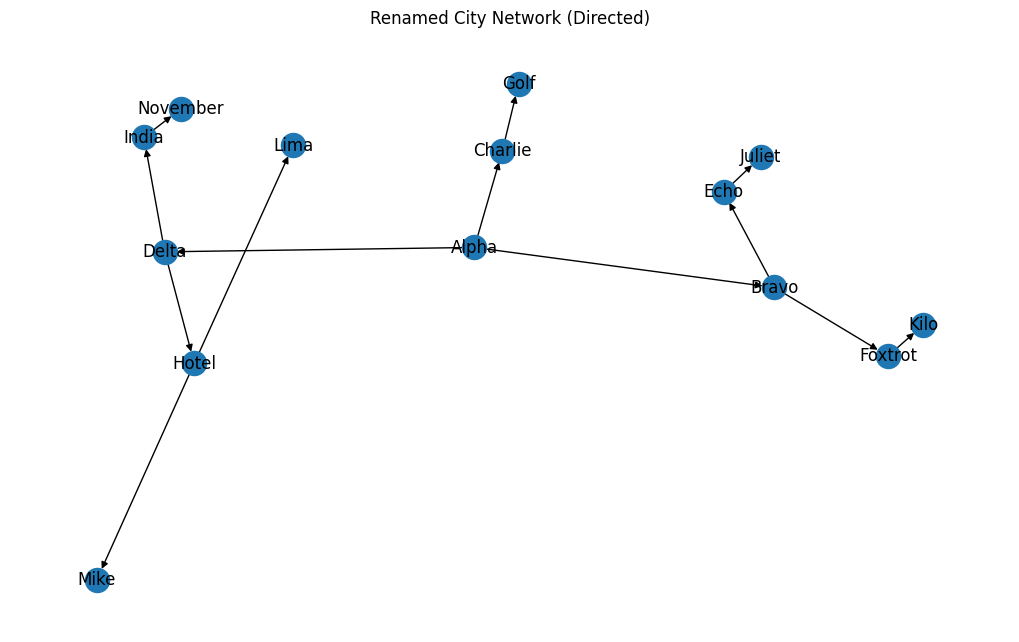

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()
for u, nbrs in renamed_graph.items():
    for v in nbrs:
        G.add_edge(u, v)

try:
    from networkx.drawing.nx_pydot import graphviz_layout
    pos = graphviz_layout(G, prog="dot")
except Exception:
    pos = nx.spring_layout(G, seed=0)

plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, arrows=True)
plt.title("Renamed City Network (Directed)")
plt.show()


- **Discovery order**: the order nodes are *first seen/enqueued*  
- **Expansion order**: the order nodes are *dequeued/expanded* (the classic “visited” order)

In [ ]:
from collections import deque

def bfs_shortest_path_and_orders(adj, start, goal):
    q = deque([start])
    parent = {start: None}
    discovered_order = [start]
    expanded_order = []

    while q:
        u = q.popleft()
        expanded_order.append(u)

        if u == goal:
            break

        for v in adj.get(u, []):
            if v not in parent:
                parent[v] = u
                discovered_order.append(v)
                
                if v == goal:
                    q.clear()
                    break
                q.append(v)

    if goal not in parent:
        return None, discovered_order, expanded_order

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path, discovered_order, expanded_order

path, discovered, expanded = bfs_shortest_path_and_orders(renamed_graph, renamed_start, renamed_goal)

path, discovered, expanded


(['Alpha', 'Delta', 'Hotel', 'Mike'],
 ['Alpha',
  'Bravo',
  'Charlie',
  'Delta',
  'Echo',
  'Foxtrot',
  'Golf',
  'Hotel',
  'India',
  'Juliet',
  'Kilo',
  'Lima',
  'Mike'],
 ['Alpha', 'Bravo', 'Charlie', 'Delta', 'Echo', 'Foxtrot', 'Golf', 'Hotel'])

- **Shortest path** (fewest hops) from start to goal  
- **Nodes visited in order** (both discovery order and expansion order)

In [12]:
print("Start:", renamed_start)
print("Goal:", renamed_goal)
print()

print("Shortest path (BFS):")
print(" → ".join(path) if path else "No path found")
print()

print("Nodes visited (DISCOVERY order = first seen/enqueued):")
print(" → ".join(discovered))
print()

print("Nodes visited (EXPANSION order = dequeued/expanded):")
print(" → ".join(expanded))


Start: Alpha
Goal: Mike

Shortest path (BFS):
Alpha → Delta → Hotel → Mike

Nodes visited (DISCOVERY order = first seen/enqueued):
Alpha → Bravo → Charlie → Delta → Echo → Foxtrot → Golf → Hotel → India → Juliet → Kilo → Lima → Mike

Nodes visited (EXPANSION order = dequeued/expanded):
Alpha → Bravo → Charlie → Delta → Echo → Foxtrot → Golf → Hotel
